<a href="https://colab.research.google.com/github/sonaliliyanahetti/Final-Year-Research-Malaria-Detection-Models/blob/main/MBD5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DATASET_PATH = "/content/drive/MyDrive/Research/cell images"
WORK_DIR = "/content/malaria_subset"

classes = ["Parasitized", "Uninfected"]

In [3]:
import pathlib
import os
import random
import shutil

SAMPLES_PER_CLASS = 1000
files_by_class = {}

for cls in classes:
    cls_dir = pathlib.Path(DATASET_PATH) / cls
    files = [str(p) for p in cls_dir.glob("*") if p.suffix.lower() in [".png",".jpg",".jpeg"]]
    random.shuffle(files)
    files_by_class[cls] = files[:SAMPLES_PER_CLASS]

splits = {"train":0.7,"val":0.15,"test":0.15}

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(WORK_DIR,split,cls),exist_ok=True)

for cls in classes:
    files = files_by_class[cls]
    n = len(files)

    n_train = int(n*0.7)
    n_val = int(n*0.15)

    train = files[:n_train]
    val = files[n_train:n_train+n_val]
    test = files[n_train+n_val:]

    for f in train:
        shutil.copy(f, os.path.join(WORK_DIR,"train",cls))
    for f in val:
        shutil.copy(f, os.path.join(WORK_DIR,"val",cls))
    for f in test:
        shutil.copy(f, os.path.join(WORK_DIR,"test",cls))

print("Dataset ready")

Dataset ready


In [4]:
import tensorflow as tf
import os

IMG_SIZE = (224,224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def make_ds(split):
    return tf.keras.utils.image_dataset_from_directory(
        os.path.join(WORK_DIR,split),
        labels="inferred",
        label_mode="binary",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=(split=="train")
    )

train_ds = make_ds("train")
val_ds   = make_ds("val")
test_ds  = make_ds("test")

print(train_ds.class_names)

Found 1400 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
['Parasitized', 'Uninfected']


In [5]:
aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

def enhance(x):
    x = tf.cast(x, tf.float32) / 255.0
    return x

def preprocess(x, y, train=False):
    x = tf.cast(x, tf.float32) / 255.0
    if train:
        x = aug(x, training=True)
    return x, y

random.seed(42)

def prepare(ds,train=False):
    ds = ds.map(lambda x,y: preprocess(x,y,train),num_parallel_calls=AUTOTUNE)
    if train:
        ds = ds.shuffle(4096)
    return ds.prefetch(AUTOTUNE)

train_ds = prepare(train_ds,True)
val_ds   = prepare(val_ds,False)
test_ds  = prepare(test_ds,False)

In [6]:
from tensorflow import keras
from tensorflow.keras import layers

def transformer(x):
    skip = x
    x = layers.LayerNormalization()(x)
    x = layers.MultiHeadAttention(num_heads=4,key_dim=x.shape[-1])(x,x)
    x = layers.Add()([x,skip])

    skip = x
    x = layers.LayerNormalization()(x)
    x = layers.Dense(512,activation="gelu")(x)
    x = layers.Dense(skip.shape[-1])(x) # Changed x.shape[-1] to skip.shape[-1] to match the skip connection dimension
    x = layers.Add()([x,skip])

    return x


def build_model():

    inp = keras.Input(shape=(224,224,3))

    x = inp
    for c in [32,64,128]:
        x = layers.Conv2D(c,3,activation="relu",padding="same")(x)
        x = layers.Conv2D(c,3,activation="relu",padding="same")(x)
        x = layers.MaxPool2D()(x)

    x = layers.Conv2D(256,8,strides=8, padding="same")(x)

    h,w = x.shape[1],x.shape[2]
    x = layers.Reshape((h*w,256))(x)

    pos = tf.range(h*w)
    x = x + layers.Embedding(h*w,256)(pos)

    for _ in range(2):
        x = transformer(x)

    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    res = x
    x = layers.Dense(512,activation="gelu")(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256,activation="gelu")(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256)(x)
    res = layers.Dense(256)(res)

    x = layers.Add()([x,res])
    x = layers.LayerNormalization()(x)

    out = layers.Dense(1,activation="sigmoid")(x)

    return keras.Model(inp,out)

model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 4, 4, 256) │  2,097,408 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 16, 256)   │          0 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 256)   │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 16, 256)   │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 256)   │  1,051,904 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 256)   │          0 │ multi_head_atten… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 256)   │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16, 512)   │    131,584 │ layer_normalizat

 Total params: 5,411,873 (20.64 MB)

 Trainable params: 5,411,873 (20.64 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
lr = tf.keras.optimizers.schedules.CosineDecay(2e-4,1000)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(lr,weight_decay=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy",tf.keras.metrics.AUC(name="auc")]
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)
]

history = model.fit(train_ds,validation_data=val_ds,epochs=15,callbacks=callbacks)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy","auc"]
)

history2 = model.fit(train_ds,validation_data=val_ds,epochs=15)

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.5136 - auc: 0.5223 - loss: 0.8346 - val_accuracy: 0.5000 - val_auc: 0.5260 - val_loss: 0.7538
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 177ms/step - accuracy: 0.5114 - auc: 0.5112 - loss: 0.7132 - val_accuracy: 0.5000 - val_auc: 0.6090 - val_loss: 0.7034
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 173ms/step - accuracy: 0.4943 - auc: 0.4772 - loss: 0.7228 - val_accuracy: 0.5000 - val_auc: 0.6823 - val_loss: 0.6909
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 179ms/step - accuracy: 0.5329 - auc: 0.5389 - loss: 0.7075 - val_accuracy: 0.5000 - val_auc: 0.7246 - val_loss: 0.7206
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.5693 - auc: 0.6197 - loss: 0.6771 - val_accuracy: 0.6267 - val_auc: 0.7786 - val_loss: 0.6333
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 178ms/step - accuracy: 0.7100 - auc: 0.7678 - loss: 0.5925 - val_accuracy: 0.7067 - val_auc: 0.7862 - val_loss: 0.6096
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
              precision    recall  f1-score   support

 Parasitized       0.79      0.74      0.76       150
  Uninfected       0.75      0.80      0.78       150

    accuracy                           0.77       300
   macro avg       0.77      0.77      0.77       300
weighted avg       0.77      0.77      0.77       300



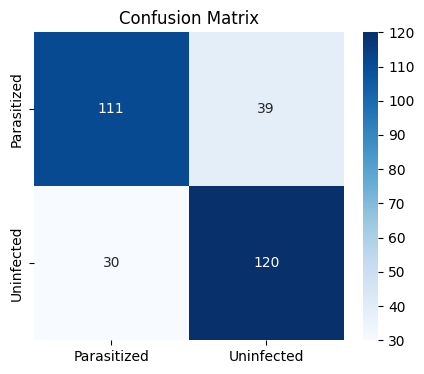

<Figure size 640x480 with 0 Axes>

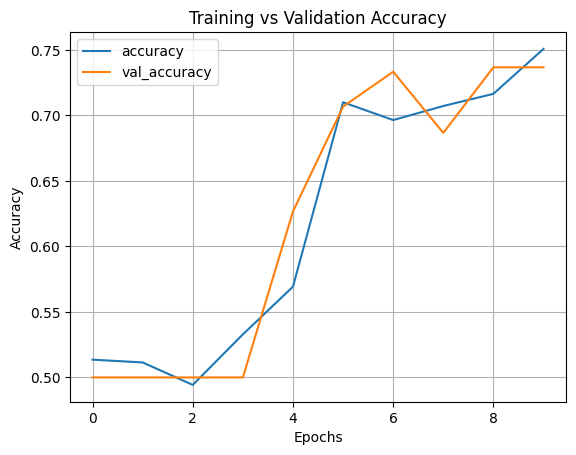

<Figure size 640x480 with 0 Axes>

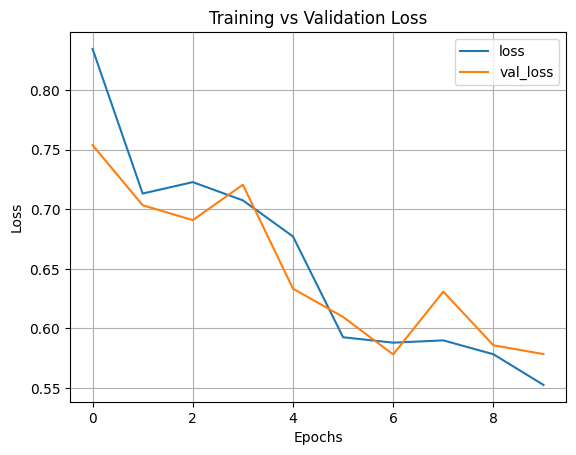

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

y_true = np.concatenate([y for _,y in test_ds])
y_pred = model.predict(test_ds).ravel()
y_hat = (y_pred>=0.5).astype(int)

print(classification_report(y_true,y_hat,target_names=classes))

cm = confusion_matrix(y_true,y_hat)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=classes,yticklabels=classes)
plt.title("Confusion Matrix")
plt.show()

history_df = pd.DataFrame(history.history)
plt.figure()
history_df[['accuracy', 'val_accuracy']].plot() # Changed 'acc' to 'accuracy'
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure()
history_df[['loss', 'val_loss']].plot()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2

def gradcam(img, original_img=None, show=True):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv, pred = grad_model(img)
        loss = pred[:, 0]

    grads = tape.gradient(loss, conv)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv = conv[0]
    heat = tf.reduce_sum(conv * pooled, axis=-1)
    heat = tf.squeeze(heat)
    heat = tf.maximum(heat, 0) / (tf.reduce_max(heat) + 1e-8)
    heat_np = heat.numpy()

    if show:
        # Use original_img if provided, else use input img
        display_img = original_img if original_img is not None else img[0].numpy()

        # Ensure display_img is in [0, 1] or [0, 255]
        if display_img.max() > 1.0:
            display_img = display_img / 255.0

        # Resize heatmap to match input image size
        h, w = display_img.shape[:2]
        heat_resized = cv2.resize(heat_np, (w, h))

        # Apply colormap to heatmap
        colormap = cm.get_cmap("jet")
        heat_colored = colormap(heat_resized)[:, :, :3]  # Drop alpha channel

        # Superimpose heatmap on original image
        superimposed = heat_colored * 0.4 + display_img * 0.6
        superimposed = np.clip(superimposed, 0, 1)

        # 3-panel plot
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(display_img)
        axes[0].set_title("Original Image")
        axes[0].axis("off")

        im = axes[1].imshow(heat_resized, cmap="jet")
        axes[1].set_title("Grad-CAM Heatmap")
        axes[1].axis("off")
        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

        axes[2].imshow(superimposed)
        axes[2].set_title(f"Superimposed  |  pred: {pred.numpy()[0][0]:.3f}")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

    return heat_np

In [22]:
def extract_species_features(img):

    img_np = img.numpy()
    img_np = ((img_np + 1) * 127.5).astype(np.uint8)

    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    hsv  = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

    features = {}

    _, mask = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    cnts,_ = cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    rbc_area = 0
    aspect_ratio = 1

    if cnts:
        c = max(cnts,key=cv2.contourArea)
        rbc_area = cv2.contourArea(c)
        x,y,w,h = cv2.boundingRect(c)
        aspect_ratio = w/(h+1e-6)

    features["rbc_area"] = rbc_area
    features["aspect_ratio"] = aspect_ratio

    _, pmask = cv2.threshold(gray,80,255,cv2.THRESH_BINARY_INV)
    lab = label(pmask)
    regs = regionprops(lab)

    features["parasite_count"] = len(regs)

    return features


/tmp/ipykernel_1595/285059079.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("jet")


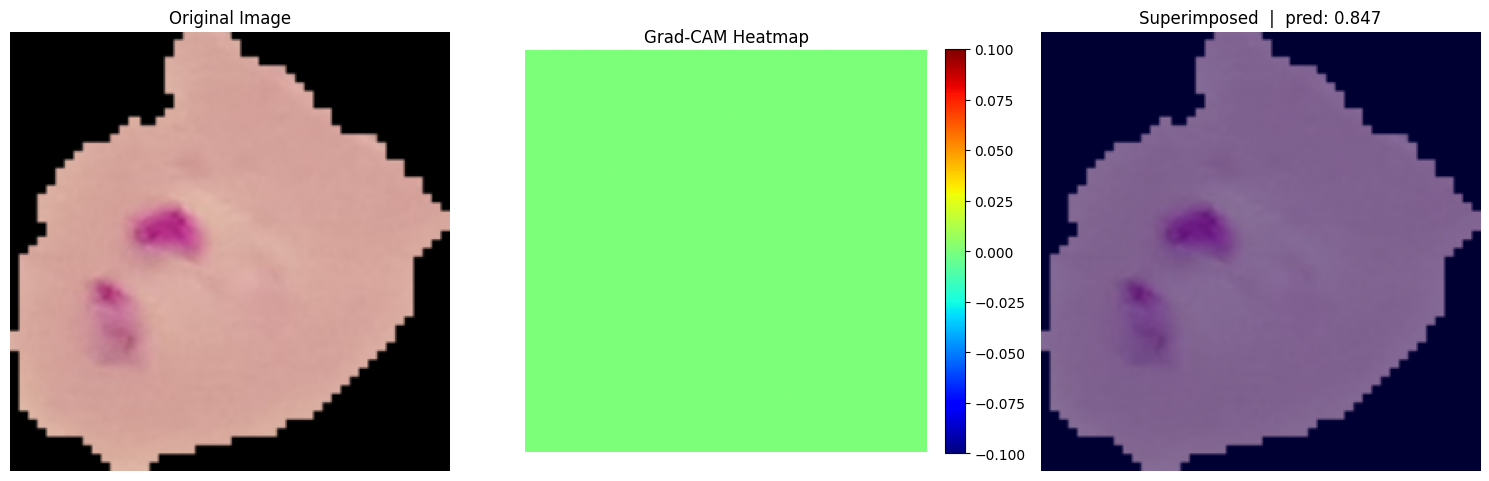

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Get a sample image from the test dataset
for image_batch, label_batch in test_ds.take(1):
    raw_img = image_batch[0].numpy()  # Get the first image as a NumPy array
    img_batch = tf.expand_dims(raw_img, axis=0) # Add batch dimension
    break

# Assuming 'last_conv' is defined elsewhere, if not, find it.
# For example, if it's not globally available, you might need to run this:
last_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
        break

if last_conv is None:
    print("Could not find a convolutional layer for Grad-CAM.")
else:
    heat = gradcam(img_batch, original_img=raw_img, show=True)

    # save heatmap to file
    plt.imsave("gradcam_heat.png", heat, cmap="jet")

In [12]:
def classify_species(f):

    scores = {
        "P.falciparum":0,
        "P.vivax":0,
        "P.malariae":0,
        "P.ovale":0,
        "P.knowlesi":0
    }

    if f["rbc_area"] < 5000:
        scores["P.falciparum"] += 2

    if f["parasite_count"] > 3:
        scores["P.knowlesi"] += 4

    if f["rbc_area"] > 8000:
        scores["P.vivax"] += 3

    if f["aspect_ratio"] > 1.2:
        scores["P.ovale"] += 3

    if f["parasite_count"] <= 1:
        scores["P.malariae"] += 2

    return max(scores, key=scores.get), scores

In [13]:
def full_prediction(image):

    x = enhance(tf.expand_dims(image,0))
    x = (x*2)-1

    prob = model.predict(x)[0][0]

    # UNCERTAINTY OPTION
    if prob < 0.45:
        return "Uninfected", None, prob
    if prob < 0.55:
        return "I am not sure", None, prob

    img_np = x[0]  # still normalized
    features = extract_species_features(img_np)

    species, scores = classify_species(features)

    return species, scores, prob

In [15]:
def visualize_prediction(image, title="Prediction Visualization"):
    pass

In [16]:
# 8. Save (use Keras native format)
model.save("/content/MDB.keras")
from google.colab import files
files.download("/content/MDB.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>